In [6]:
import os
import sys
import numpy as np
import xarray as xr
import geopandas as gpd
import shapely.vectorized as sv

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

import warnings
warnings.filterwarnings('ignore')

In [2]:
dir_base = os.path.join('/','media','arturo','T9','Data','Italy','Satellite','2_MEV','uncorrected')
veneto_dir = os.path.join('/','media','arturo','T9','Data','shapes','Europa','Italy')

In [13]:
lon_min, lon_max, lat_min, lat_max, area = 6.5, 19, 36.5, 48, 'ITALY'

In [8]:
if os.path.exists(veneto_dir):
    ITALY = gpd.read_file(os.path.join(veneto_dir,'Italy_clear.geojson'))
else:
    raise SystemExit(f"File not found: {veneto_dir}")

italy_geom = ITALY.union_all()

In [11]:
inputfile = os.path.join(dir_base,'ITALY_DOWN_IMERG_1dy_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc')
DATA = xr.open_dataset(inputfile)
lon2d_IM, lat2d_IM = np.meshgrid(DATA.lon, DATA.lat)

mask_italy = sv.contains(italy_geom, lon2d_IM, lat2d_IM)
IMERG_mev = DATA.Mev_s.where(mask_italy).values
IMERG_med = DATA.Mev_d.where(mask_italy).values

In [88]:
print(np.nanmin(IMERG_mev[3,:,:]),np.nanmax(IMERG_mev[3,:,:]))
print(np.nanmin(IMERG_med[3,:,:]-IMERG_mev[3,:,:]),np.nanmax(IMERG_med[3,:,:]-IMERG_mev[3,:,:]))

73.70529917219304 251.15276485260728
4.527627559541543 23.1301023913841


In [ ]:
Mev_cmap = plt.cm.Spectral_r
Mev_levels = np.arange(70, 270, 10)
Mev_norm = mcolors.BoundaryNorm(boundaries=Mev_levels, ncolors=Mev_cmap.N)

Diff_cmap = plt.cm.Reds
Diff_levels = np.arange(4, 26, 2)
Diff_norm = mcolors.BoundaryNorm(boundaries=Diff_levels, ncolors=Diff_cmap.N)

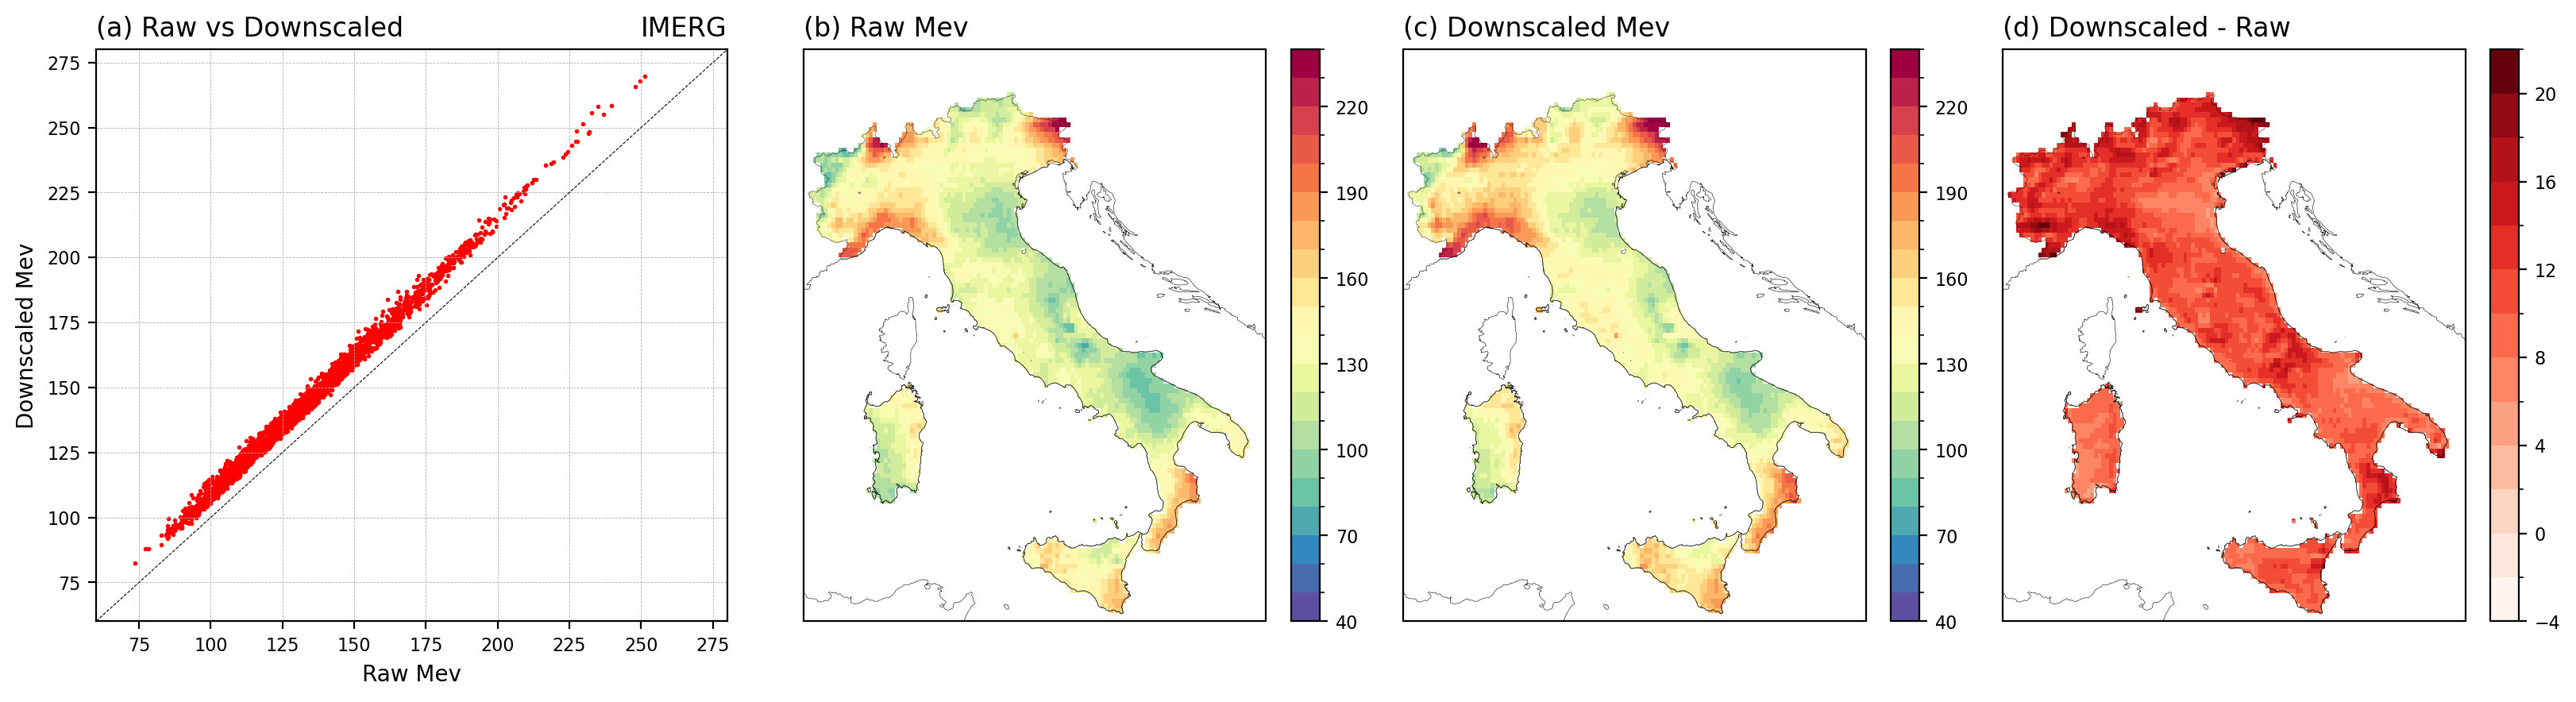

In [95]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(17,4),dpi=200)
gs = gridspec.GridSpec(1,4)

# ====================================================================================================================
ax1 = plt.subplot(gs[0, 0])
ax1.scatter(IMERG_mev[3,:,:].flatten(), IMERG_med[3,:,:].flatten(), s=1, c='r')
ax1.plot(np.arange(300),np.arange(300),'--k', linewidth=0.4, label='Identity line')
ax1.tick_params(axis='both', which='major', labelsize=8)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_title('(a) Raw vs Downscaled', fontsize=12, loc='left')
ax1.set_title('IMERG', fontsize=12, loc='right')
ax1.set_xlabel('Raw Mev',fontsize=10)
ax1.set_ylabel('Downscaled Mev',fontsize=10)
ax1.set_xlim(60,280)
ax1.set_ylim(60,280)

# ====================================================================================================================
ax1 = plt.subplot(gs[0, 1], projection = proj)
ax1.coastlines(linewidth=0.2)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.3, zorder=21, alpha=0.5)
a1 = ax1.pcolormesh(lon2d_IM, lat2d_IM, IMERG_mev[3,:,:], norm=Mev_norm, cmap=Mev_cmap)
cbar = plt.colorbar(a1, ax=ax1, fraction=0.056, pad=0.04)
cbar.ax.tick_params(labelsize=8)
ax1.set_title('(b) Raw Mev', fontsize=12, loc='left')

# ====================================================================================================================
ax1 = plt.subplot(gs[0, 2], projection = proj)
ax1.coastlines(linewidth=0.2)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.3, zorder=21, alpha=0.5)
a1 = ax1.pcolormesh(lon2d_IM, lat2d_IM, IMERG_med[3,:,:], norm=Mev_norm, cmap=Mev_cmap)
cbar = plt.colorbar(a1, ax=ax1, fraction=0.056, pad=0.04)
cbar.ax.tick_params(labelsize=8)
ax1.set_title('(c) Downscaled Mev', fontsize=12, loc='left')

# ====================================================================================================================
ax1 = plt.subplot(gs[0, 3], projection = proj)
ax1.coastlines(linewidth=0.2)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.3, zorder=21, alpha=0.5)
a1 = ax1.pcolormesh(lon2d_IM, lat2d_IM, IMERG_med[3,:,:]-IMERG_mev[3,:,:], norm=Diff_norm, cmap=Diff_cmap)
cbar = plt.colorbar(a1, ax=ax1, fraction=0.056, pad=0.04)
cbar.ax.tick_params(labelsize=8)
ax1.set_title('(d) Downscaled - Raw', fontsize=12, loc='left')

# ====================================================================================================================
plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=-0.05, hspace=0.08)

In [96]:
inputfile = os.path.join(dir_base,'ITALY_DOWN_GSMaP_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc')
DATA = xr.open_dataset(inputfile)
lon2d_IM, lat2d_IM = np.meshgrid(DATA.lon, DATA.lat)

mask_italy = sv.contains(italy_geom, lon2d_IM, lat2d_IM)
GSMaP_mev = DATA.Mev_s.where(mask_italy).values
GSMaP_med = DATA.Mev_d.where(mask_italy).values

In [97]:
print(np.nanmin(GSMaP_mev[3,:,:]),np.nanmax(GSMaP_mev[3,:,:]))
print(np.nanmin(GSMaP_med[3,:,:]-GSMaP_mev[3,:,:]),np.nanmax(GSMaP_med[3,:,:]-GSMaP_mev[3,:,:]))

47.00240902004858 232.90200986815762
-3.1610358165039685 12.497726004033836


In [98]:
Mev_cmap = plt.cm.Spectral_r
Mev_levels = np.arange(40, 250, 10)
Mev_norm = mcolors.BoundaryNorm(boundaries=Mev_levels, ncolors=Mev_cmap.N)

Diff_cmap = plt.cm.Reds
Diff_levels = np.arange(-4, 24, 2)
Diff_norm = mcolors.BoundaryNorm(boundaries=Diff_levels, ncolors=Diff_cmap.N)

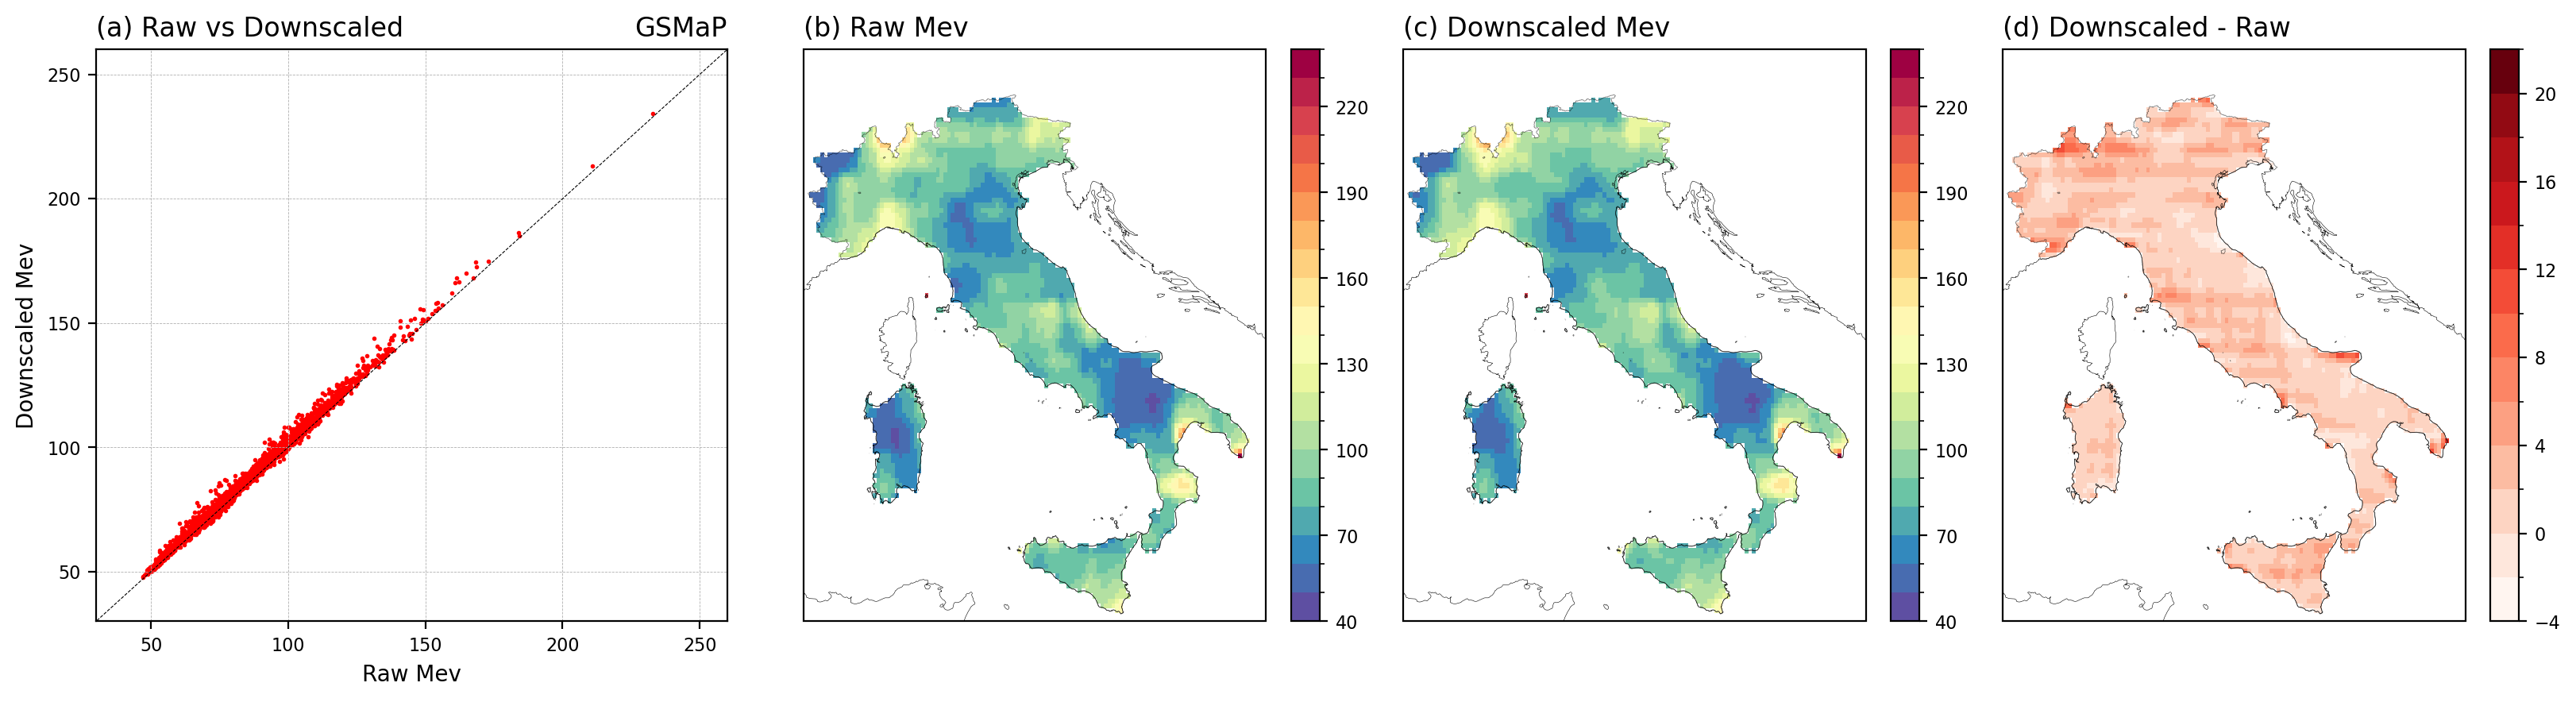

In [99]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(17,4),dpi=200)
gs = gridspec.GridSpec(1,4)

# ====================================================================================================================
ax1 = plt.subplot(gs[0, 0])
ax1.scatter(GSMaP_mev[3,:,:].flatten(), GSMaP_med[3,:,:].flatten(), s=1, c='r')
ax1.plot(np.arange(300),np.arange(300),'--k', linewidth=0.4, label='Identity line')
ax1.tick_params(axis='both', which='major', labelsize=8)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_title('(a) Raw vs Downscaled', fontsize=12, loc='left')
ax1.set_title('GSMaP', fontsize=12, loc='right')
ax1.set_xlabel('Raw Mev',fontsize=10)
ax1.set_ylabel('Downscaled Mev',fontsize=10)
ax1.set_xlim(30,260)
ax1.set_ylim(30,260)

# ====================================================================================================================
ax1 = plt.subplot(gs[0, 1], projection = proj)
ax1.coastlines(linewidth=0.2)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.3, zorder=21, alpha=0.5)
a1 = ax1.pcolormesh(lon2d_IM, lat2d_IM, GSMaP_mev[3,:,:], norm=Mev_norm, cmap=Mev_cmap)
cbar = plt.colorbar(a1, ax=ax1, fraction=0.056, pad=0.04)
cbar.ax.tick_params(labelsize=8)
ax1.set_title('(b) Raw Mev', fontsize=12, loc='left')

# ====================================================================================================================
ax1 = plt.subplot(gs[0, 2], projection = proj)
ax1.coastlines(linewidth=0.2)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.3, zorder=21, alpha=0.5)
a1 = ax1.pcolormesh(lon2d_IM, lat2d_IM, GSMaP_med[3,:,:], norm=Mev_norm, cmap=Mev_cmap)
cbar = plt.colorbar(a1, ax=ax1, fraction=0.056, pad=0.04)
cbar.ax.tick_params(labelsize=8)
ax1.set_title('(c) Downscaled Mev', fontsize=12, loc='left')

# ====================================================================================================================
ax1 = plt.subplot(gs[0, 3], projection = proj)
ax1.coastlines(linewidth=0.2)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.3, zorder=21, alpha=0.5)
a1 = ax1.pcolormesh(lon2d_IM, lat2d_IM, GSMaP_med[3,:,:]-GSMaP_mev[3,:,:], norm=Diff_norm, cmap=Diff_cmap)
cbar = plt.colorbar(a1, ax=ax1, fraction=0.056, pad=0.04)
cbar.ax.tick_params(labelsize=8)
ax1.set_title('(d) Downscaled - Raw', fontsize=12, loc='left')

# ====================================================================================================================
plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=-0.05, hspace=0.08)

In [100]:
inputfile = os.path.join(dir_base,'ITALY_DOWN_MSWEP_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc')
DATA = xr.open_dataset(inputfile)
lon2d_IM, lat2d_IM = np.meshgrid(DATA.lon, DATA.lat)

mask_italy = sv.contains(italy_geom, lon2d_IM, lat2d_IM)
MSWEP_mev = DATA.Mev_s.where(mask_italy).values
MSWEP_med = DATA.Mev_d.where(mask_italy).values

In [101]:
print(np.nanmin(MSWEP_mev[3,:,:]),np.nanmax(MSWEP_mev[3,:,:]))
print(np.nanmin(MSWEP_med[3,:,:]-MSWEP_mev[3,:,:]),np.nanmax(MSWEP_med[3,:,:]-MSWEP_mev[3,:,:]))

40.09013615185834 256.97527094125866
-7.37817635710033 25.439866479782623


In [102]:
Mev_cmap = plt.cm.Spectral_r
Mev_levels = np.arange(40, 270, 10)
Mev_norm = mcolors.BoundaryNorm(boundaries=Mev_levels, ncolors=Mev_cmap.N)

Diff_cmap = plt.cm.Reds
Diff_levels = np.arange(-7, 28, 2)
Diff_norm = mcolors.BoundaryNorm(boundaries=Diff_levels, ncolors=Diff_cmap.N)

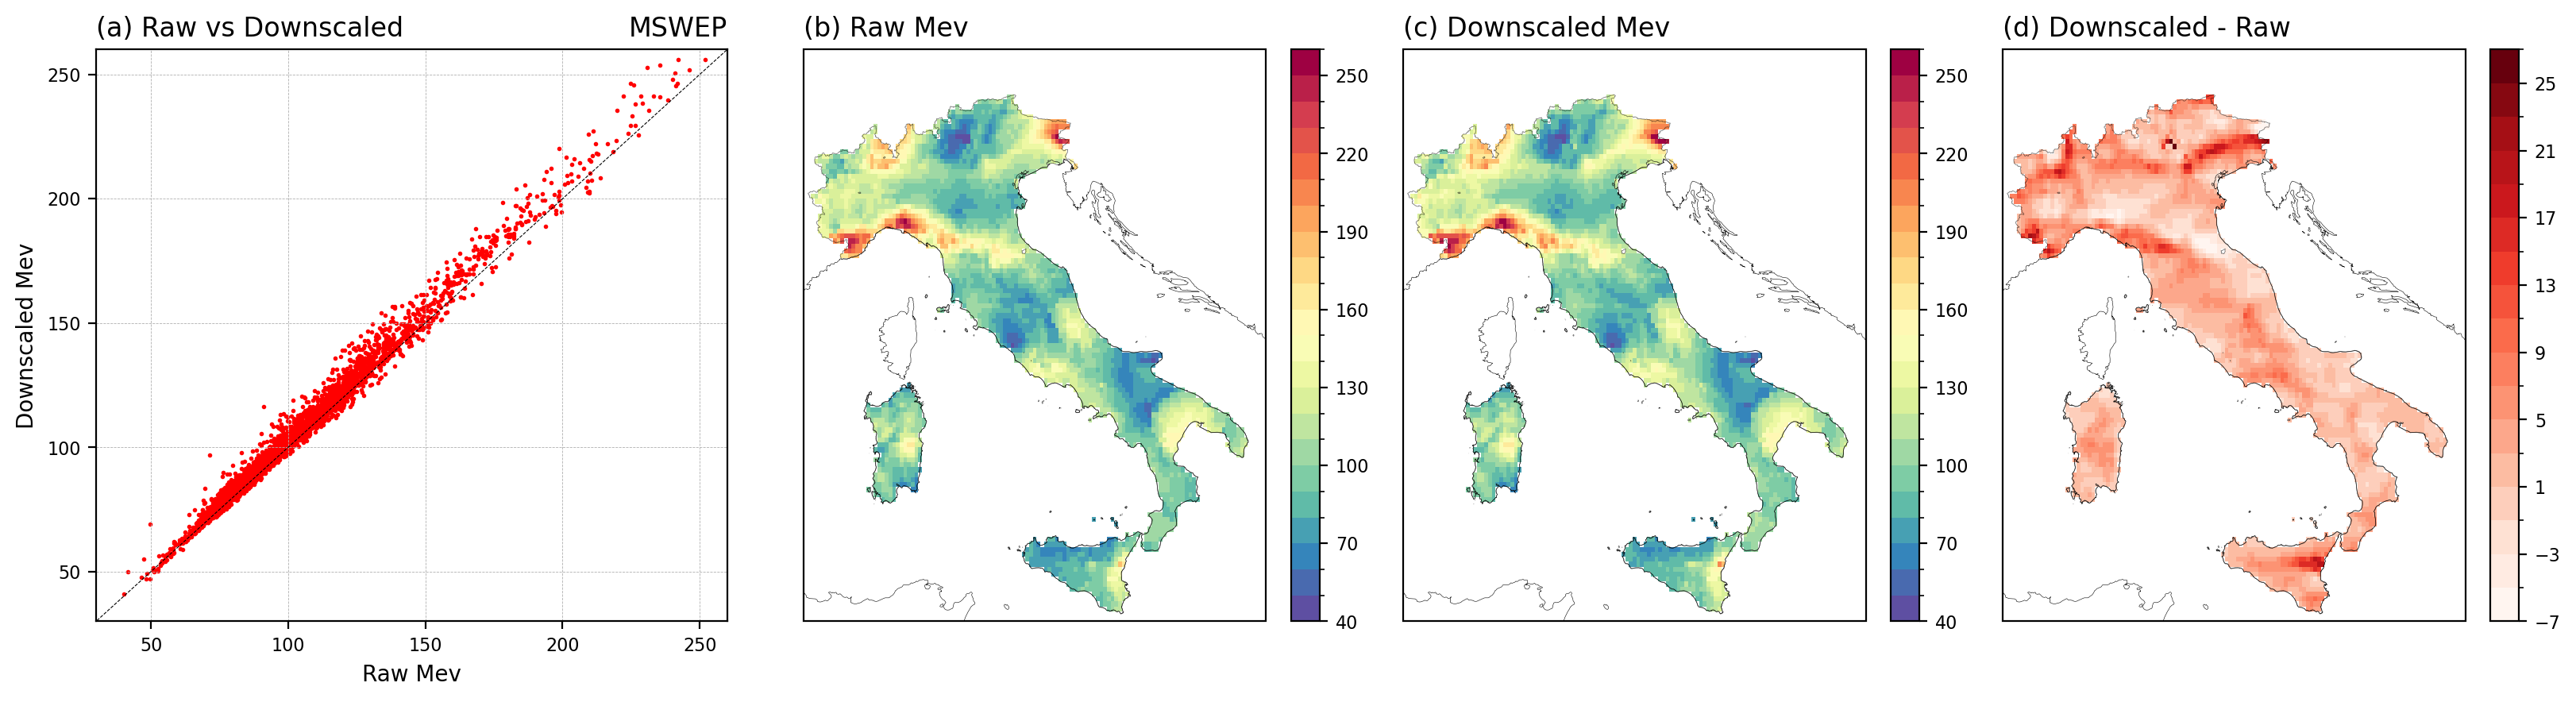

In [103]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(17,4),dpi=200)
gs = gridspec.GridSpec(1,4)

# ====================================================================================================================
ax1 = plt.subplot(gs[0, 0])
ax1.scatter(MSWEP_mev[3,:,:].flatten(), MSWEP_med[3,:,:].flatten(), s=1, c='r')
ax1.plot(np.arange(300),np.arange(300),'--k', linewidth=0.4, label='Identity line')
ax1.tick_params(axis='both', which='major', labelsize=8)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_title('(a) Raw vs Downscaled', fontsize=12, loc='left')
ax1.set_title('MSWEP', fontsize=12, loc='right')
ax1.set_xlabel('Raw Mev',fontsize=10)
ax1.set_ylabel('Downscaled Mev',fontsize=10)
ax1.set_xlim(30,260)
ax1.set_ylim(30,260)

# ====================================================================================================================
ax1 = plt.subplot(gs[0, 1], projection = proj)
ax1.coastlines(linewidth=0.2)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.3, zorder=21, alpha=0.5)
a1 = ax1.pcolormesh(lon2d_IM, lat2d_IM, MSWEP_mev[3,:,:], norm=Mev_norm, cmap=Mev_cmap)
cbar = plt.colorbar(a1, ax=ax1, fraction=0.056, pad=0.04)
cbar.ax.tick_params(labelsize=8)
ax1.set_title('(b) Raw Mev', fontsize=12, loc='left')

# ====================================================================================================================
ax1 = plt.subplot(gs[0, 2], projection = proj)
ax1.coastlines(linewidth=0.2)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.3, zorder=21, alpha=0.5)
a1 = ax1.pcolormesh(lon2d_IM, lat2d_IM, MSWEP_med[3,:,:], norm=Mev_norm, cmap=Mev_cmap)
cbar = plt.colorbar(a1, ax=ax1, fraction=0.056, pad=0.04)
cbar.ax.tick_params(labelsize=8)
ax1.set_title('(c) Downscaled Mev', fontsize=12, loc='left')

# ====================================================================================================================
ax1 = plt.subplot(gs[0, 3], projection = proj)
ax1.coastlines(linewidth=0.2)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.3, zorder=21, alpha=0.5)
a1 = ax1.pcolormesh(lon2d_IM, lat2d_IM, MSWEP_med[3,:,:]-MSWEP_mev[3,:,:], norm=Diff_norm, cmap=Diff_cmap)
cbar = plt.colorbar(a1, ax=ax1, fraction=0.056, pad=0.04)
cbar.ax.tick_params(labelsize=8)
ax1.set_title('(d) Downscaled - Raw', fontsize=12, loc='left')

# ====================================================================================================================
plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=-0.05, hspace=0.08)

In [104]:
inputfile = os.path.join(dir_base,'ITALY_DOWN_ERA5_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc')
DATA = xr.open_dataset(inputfile)
lon2d_IM, lat2d_IM = np.meshgrid(DATA.lon, DATA.lat)

mask_italy = sv.contains(italy_geom, lon2d_IM, lat2d_IM)
ERA5_mev = DATA.Mev_s.where(mask_italy).values
ERA5_med = DATA.Mev_d.where(mask_italy).values

In [105]:
print(np.nanmin(ERA5_mev[3,:,:]),np.nanmax(ERA5_mev[3,:,:]))
print(np.nanmin(ERA5_med[3,:,:]-ERA5_mev[3,:,:]),np.nanmax(ERA5_med[3,:,:]-ERA5_mev[3,:,:]))

58.1442642035432 251.83893570235384
-3.0048420397591684 36.48637961145653


In [106]:
Mev_cmap = plt.cm.Spectral_r
Mev_levels = np.arange(50, 270, 10)
Mev_norm = mcolors.BoundaryNorm(boundaries=Mev_levels, ncolors=Mev_cmap.N)

Diff_cmap = plt.cm.Reds
Diff_levels = np.arange(-3, 38, 2)
Diff_norm = mcolors.BoundaryNorm(boundaries=Diff_levels, ncolors=Diff_cmap.N)

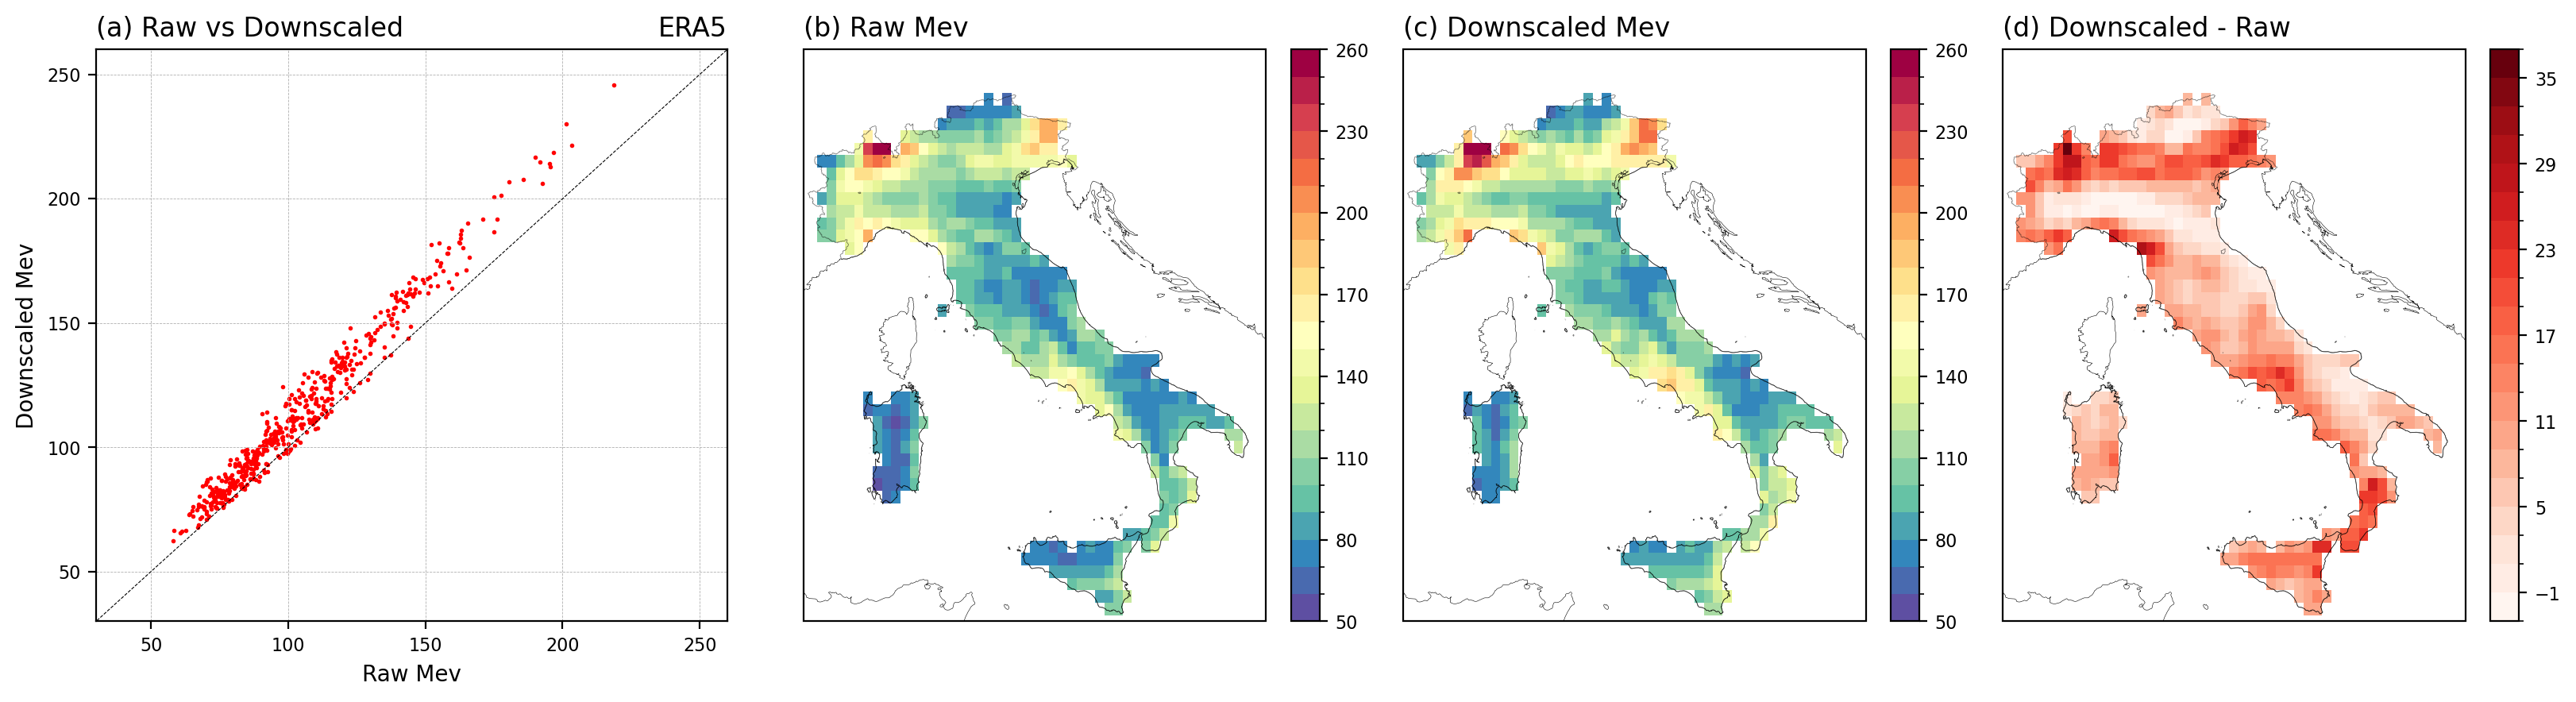

In [107]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(17,4),dpi=200)
gs = gridspec.GridSpec(1,4)

# ====================================================================================================================
ax1 = plt.subplot(gs[0, 0])
ax1.scatter(ERA5_mev[3,:,:].flatten(), ERA5_med[3,:,:].flatten(), s=1, c='r')
ax1.plot(np.arange(300),np.arange(300),'--k', linewidth=0.4, label='Identity line')
ax1.tick_params(axis='both', which='major', labelsize=8)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_title('(a) Raw vs Downscaled', fontsize=12, loc='left')
ax1.set_title('ERA5', fontsize=12, loc='right')
ax1.set_xlabel('Raw Mev',fontsize=10)
ax1.set_ylabel('Downscaled Mev',fontsize=10)
ax1.set_xlim(30,260)
ax1.set_ylim(30,260)

# ====================================================================================================================
ax1 = plt.subplot(gs[0, 1], projection = proj)
ax1.coastlines(linewidth=0.2)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.3, zorder=21, alpha=0.5)
a1 = ax1.pcolormesh(lon2d_IM, lat2d_IM, ERA5_mev[3,:,:], norm=Mev_norm, cmap=Mev_cmap)
cbar = plt.colorbar(a1, ax=ax1, fraction=0.056, pad=0.04)
cbar.ax.tick_params(labelsize=8)
ax1.set_title('(b) Raw Mev', fontsize=12, loc='left')

# ====================================================================================================================
ax1 = plt.subplot(gs[0, 2], projection = proj)
ax1.coastlines(linewidth=0.2)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.3, zorder=21, alpha=0.5)
a1 = ax1.pcolormesh(lon2d_IM, lat2d_IM, ERA5_med[3,:,:], norm=Mev_norm, cmap=Mev_cmap)
cbar = plt.colorbar(a1, ax=ax1, fraction=0.056, pad=0.04)
cbar.ax.tick_params(labelsize=8)
ax1.set_title('(c) Downscaled Mev', fontsize=12, loc='left')

# ====================================================================================================================
ax1 = plt.subplot(gs[0, 3], projection = proj)
ax1.coastlines(linewidth=0.2)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.3, zorder=21, alpha=0.5)
a1 = ax1.pcolormesh(lon2d_IM, lat2d_IM, ERA5_med[3,:,:]-ERA5_mev[3,:,:], norm=Diff_norm, cmap=Diff_cmap)
cbar = plt.colorbar(a1, ax=ax1, fraction=0.056, pad=0.04)
cbar.ax.tick_params(labelsize=8)
ax1.set_title('(d) Downscaled - Raw', fontsize=12, loc='left')

# ====================================================================================================================
plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=-0.05, hspace=0.08)

In [108]:
inputfile = os.path.join(dir_base,'ITALY_DOWN_CHIRPS_1dy_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc')
DATA = xr.open_dataset(inputfile)
lon2d_IM, lat2d_IM = np.meshgrid(DATA.lon, DATA.lat)

mask_italy = sv.contains(italy_geom, lon2d_IM, lat2d_IM)
CHIRPS_mev = DATA.Mev_s.where(mask_italy).values
CHIRPS_med = DATA.Mev_d.where(mask_italy).values

In [109]:
print(np.nanmin(CHIRPS_mev[3,:,:]),np.nanmax(CHIRPS_mev[3,:,:]))
print(np.nanmin(CHIRPS_med[3,:,:]-CHIRPS_mev[3,:,:]),np.nanmax(CHIRPS_med[3,:,:]-CHIRPS_mev[3,:,:]))

44.20758567915329 212.83701983798593
5.613085400000003 201.26517214000003


In [113]:
Mev_cmap = plt.cm.Spectral_r
Mev_levels = np.arange(40, 230, 10)
Mev_norm = mcolors.BoundaryNorm(boundaries=Mev_levels, ncolors=Mev_cmap.N)

Diff_cmap = plt.cm.Reds
Diff_levels = np.arange(5, 220, 20)
Diff_norm = mcolors.BoundaryNorm(boundaries=Diff_levels, ncolors=Diff_cmap.N)

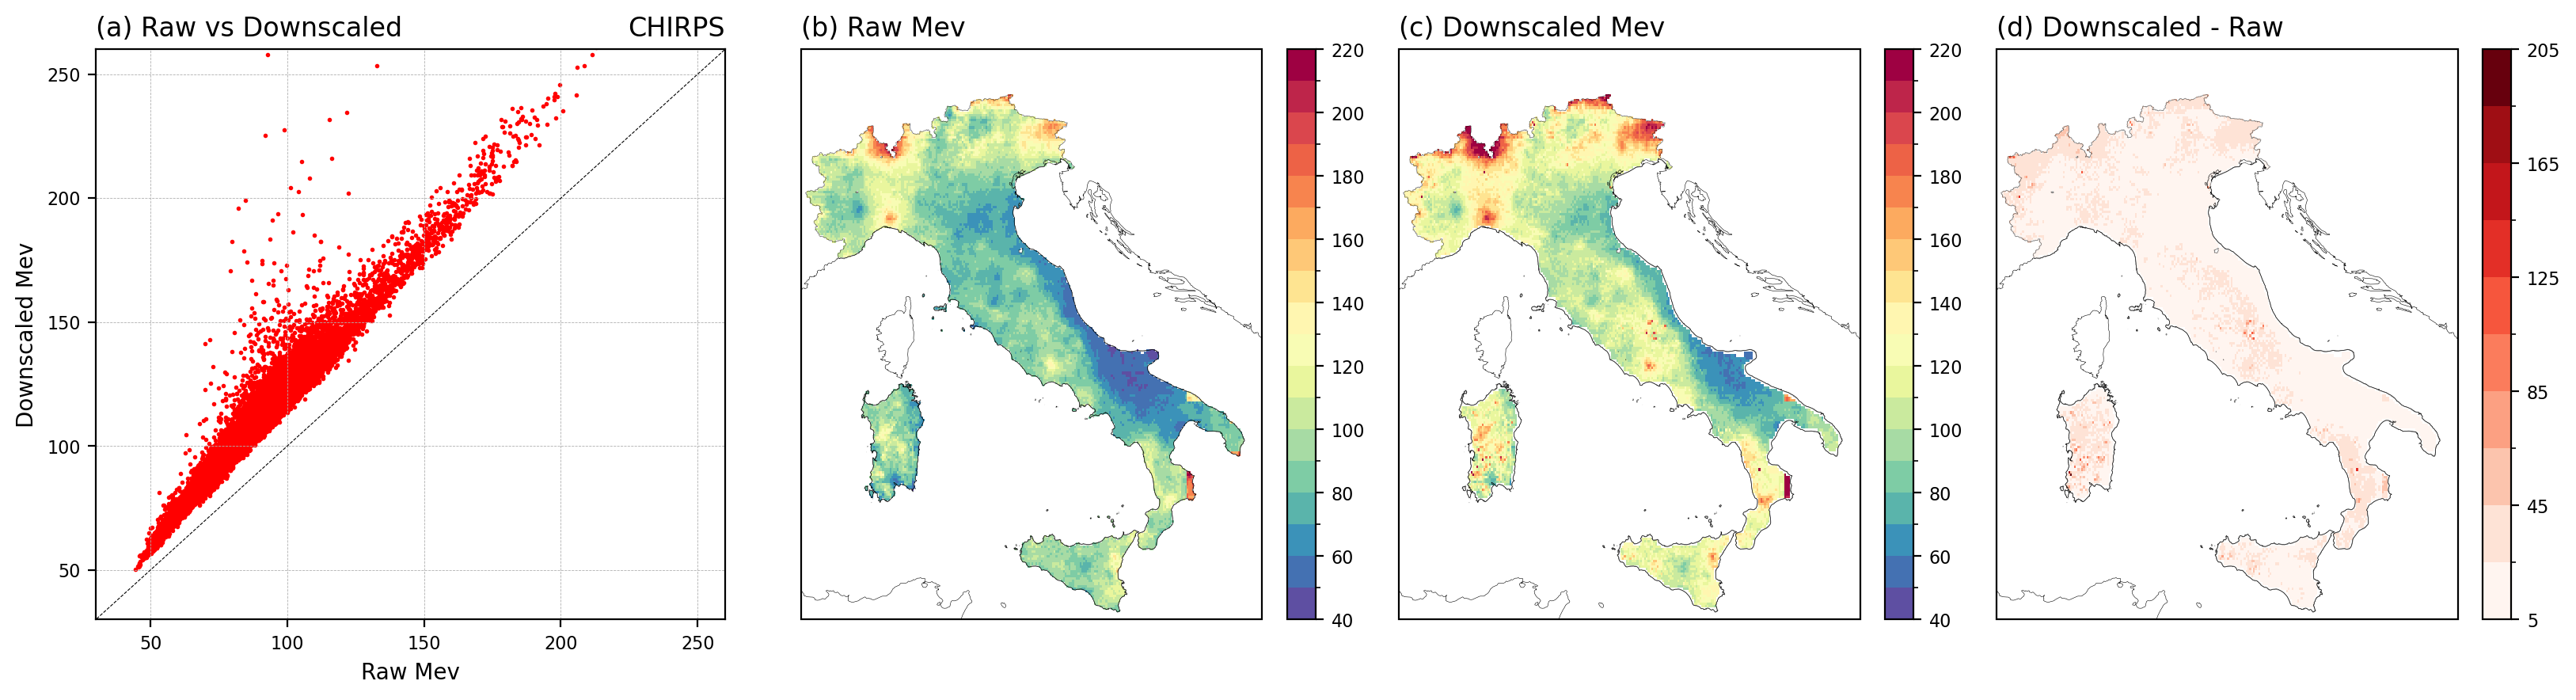

In [114]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(17,4),dpi=200)
gs = gridspec.GridSpec(1,4)

# ====================================================================================================================
ax1 = plt.subplot(gs[0, 0])
ax1.scatter(CHIRPS_mev[3,:,:].flatten(), CHIRPS_med[3,:,:].flatten(), s=1, c='r')
ax1.plot(np.arange(300),np.arange(300),'--k', linewidth=0.4, label='Identity line')
ax1.tick_params(axis='both', which='major', labelsize=8)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_title('(a) Raw vs Downscaled', fontsize=12, loc='left')
ax1.set_title('CHIRPS', fontsize=12, loc='right')
ax1.set_xlabel('Raw Mev',fontsize=10)
ax1.set_ylabel('Downscaled Mev',fontsize=10)
ax1.set_xlim(30,260)
ax1.set_ylim(30,260)

# ====================================================================================================================
ax1 = plt.subplot(gs[0, 1], projection = proj)
ax1.coastlines(linewidth=0.2)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.3, zorder=21, alpha=0.5)
a1 = ax1.pcolormesh(lon2d_IM, lat2d_IM, CHIRPS_mev[3,:,:], norm=Mev_norm, cmap=Mev_cmap)
cbar = plt.colorbar(a1, ax=ax1, fraction=0.056, pad=0.04)
cbar.ax.tick_params(labelsize=8)
ax1.set_title('(b) Raw Mev', fontsize=12, loc='left')

# ====================================================================================================================
ax1 = plt.subplot(gs[0, 2], projection = proj)
ax1.coastlines(linewidth=0.2)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.3, zorder=21, alpha=0.5)
a1 = ax1.pcolormesh(lon2d_IM, lat2d_IM, CHIRPS_med[3,:,:], norm=Mev_norm, cmap=Mev_cmap)
cbar = plt.colorbar(a1, ax=ax1, fraction=0.056, pad=0.04)
cbar.ax.tick_params(labelsize=8)
ax1.set_title('(c) Downscaled Mev', fontsize=12, loc='left')

# ====================================================================================================================
ax1 = plt.subplot(gs[0, 3], projection = proj)
ax1.coastlines(linewidth=0.2)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.3, zorder=21, alpha=0.5)
a1 = ax1.pcolormesh(lon2d_IM, lat2d_IM, CHIRPS_med[3,:,:]-CHIRPS_mev[3,:,:], norm=Diff_norm, cmap=Diff_cmap)
cbar = plt.colorbar(a1, ax=ax1, fraction=0.056, pad=0.04)
cbar.ax.tick_params(labelsize=8)
ax1.set_title('(d) Downscaled - Raw', fontsize=12, loc='left')

# ====================================================================================================================
plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=-0.05, hspace=0.08)

In [115]:
inputfile = os.path.join(dir_base,'ITALY_DOWN_CMORPH_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc')
DATA = xr.open_dataset(inputfile)
lon2d_IM, lat2d_IM = np.meshgrid(DATA.lon, DATA.lat)

mask_italy = sv.contains(italy_geom, lon2d_IM, lat2d_IM)
CMORPH_mev = DATA.Mev_s.where(mask_italy).values
CMORPH_med = DATA.Mev_d.where(mask_italy).values

In [116]:
print(np.nanmin(CMORPH_mev[3,:,:]),np.nanmax(CMORPH_mev[3,:,:]))
print(np.nanmin(CMORPH_med[3,:,:]-CMORPH_mev[3,:,:]),np.nanmax(CMORPH_med[3,:,:]-CMORPH_mev[3,:,:]))

53.094338254016684 267.8670533014582
-4.224337552693626 52.26133350290826


In [117]:
Mev_cmap = plt.cm.Spectral_r
Mev_levels = np.arange(50, 280, 10)
Mev_norm = mcolors.BoundaryNorm(boundaries=Mev_levels, ncolors=Mev_cmap.N)

Diff_cmap = plt.cm.Reds
Diff_levels = np.arange(-4, 56, 2)
Diff_norm = mcolors.BoundaryNorm(boundaries=Diff_levels, ncolors=Diff_cmap.N)

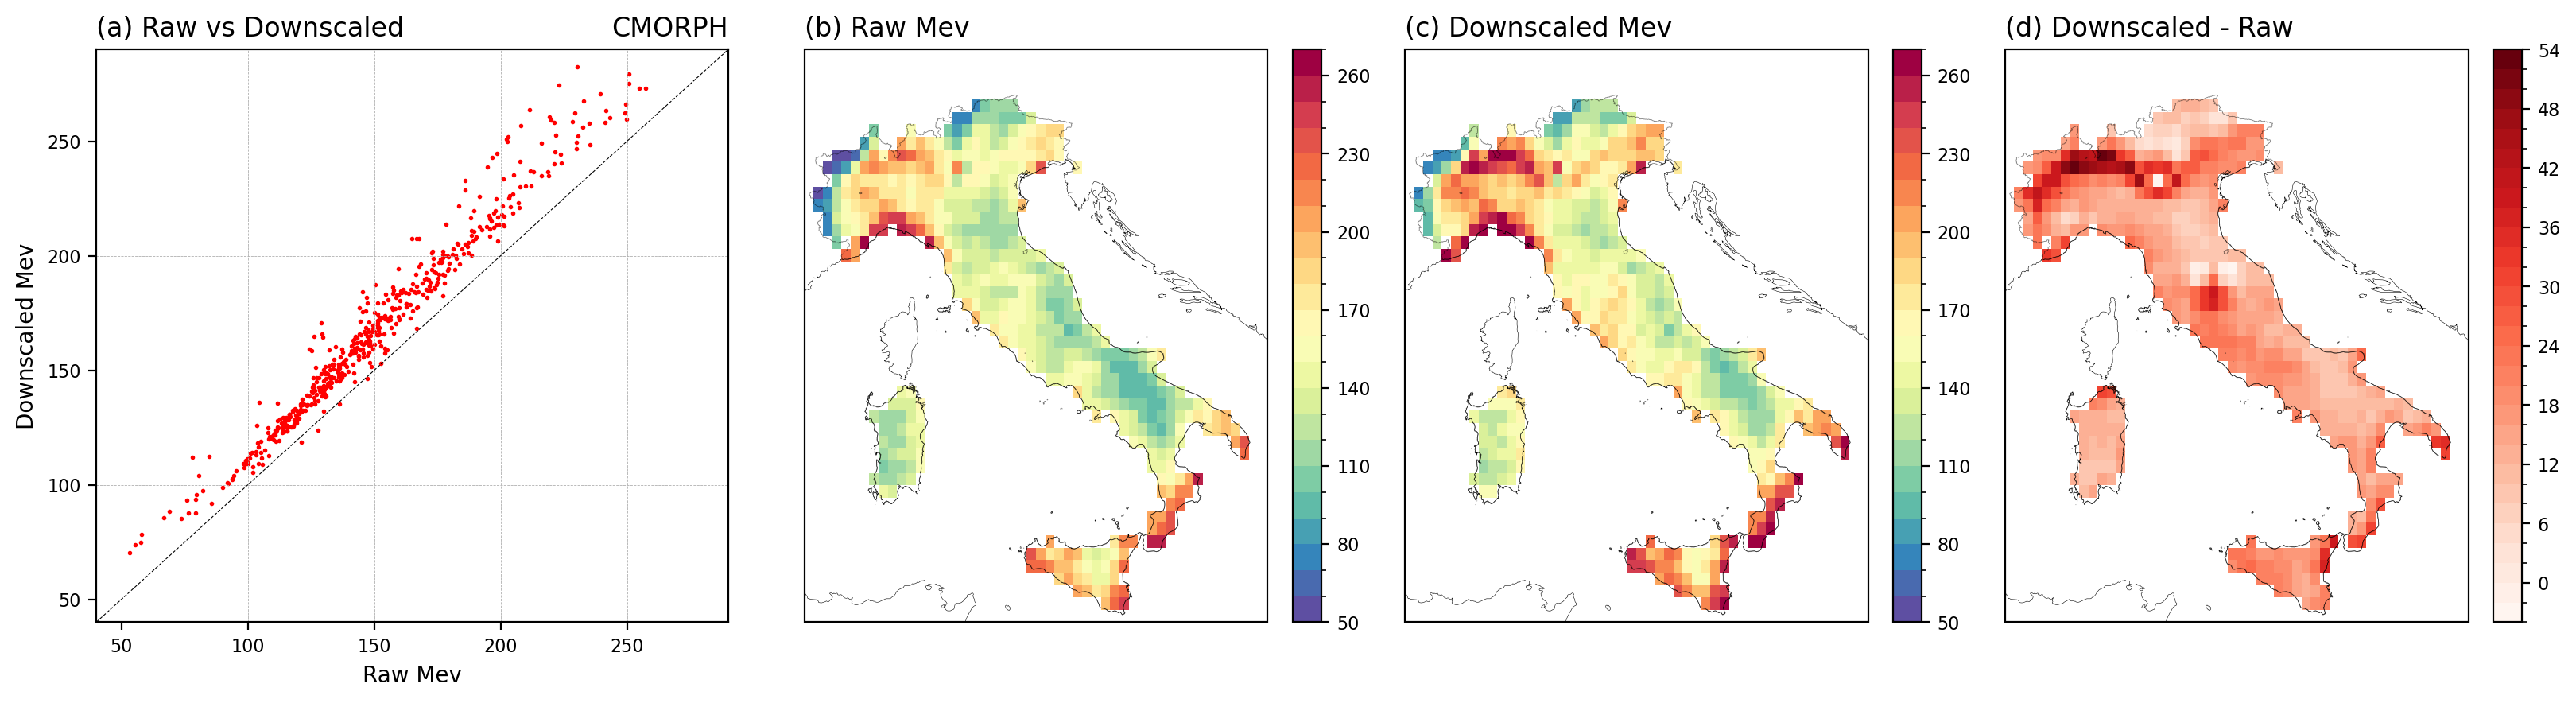

In [119]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(17,4),dpi=200)
gs = gridspec.GridSpec(1,4)

# ====================================================================================================================
ax1 = plt.subplot(gs[0, 0])
ax1.scatter(CMORPH_mev[3,:,:].flatten(), CMORPH_med[3,:,:].flatten(), s=1, c='r')
ax1.plot(np.arange(300),np.arange(300),'--k', linewidth=0.4, label='Identity line')
ax1.tick_params(axis='both', which='major', labelsize=8)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_title('(a) Raw vs Downscaled', fontsize=12, loc='left')
ax1.set_title('CMORPH', fontsize=12, loc='right')
ax1.set_xlabel('Raw Mev',fontsize=10)
ax1.set_ylabel('Downscaled Mev',fontsize=10)
ax1.set_xlim(40,290)
ax1.set_ylim(40,290)

# ====================================================================================================================
ax1 = plt.subplot(gs[0, 1], projection = proj)
ax1.coastlines(linewidth=0.2)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.3, zorder=21, alpha=0.5)
a1 = ax1.pcolormesh(lon2d_IM, lat2d_IM, CMORPH_mev[3,:,:], norm=Mev_norm, cmap=Mev_cmap)
cbar = plt.colorbar(a1, ax=ax1, fraction=0.056, pad=0.04)
cbar.ax.tick_params(labelsize=8)
ax1.set_title('(b) Raw Mev', fontsize=12, loc='left')

# ====================================================================================================================
ax1 = plt.subplot(gs[0, 2], projection = proj)
ax1.coastlines(linewidth=0.2)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.3, zorder=21, alpha=0.5)
a1 = ax1.pcolormesh(lon2d_IM, lat2d_IM, CMORPH_med[3,:,:], norm=Mev_norm, cmap=Mev_cmap)
cbar = plt.colorbar(a1, ax=ax1, fraction=0.056, pad=0.04)
cbar.ax.tick_params(labelsize=8)
ax1.set_title('(c) Downscaled Mev', fontsize=12, loc='left')

# ====================================================================================================================
ax1 = plt.subplot(gs[0, 3], projection = proj)
ax1.coastlines(linewidth=0.2)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.3, zorder=21, alpha=0.5)
a1 = ax1.pcolormesh(lon2d_IM, lat2d_IM, CMORPH_med[3,:,:]-CMORPH_mev[3,:,:], norm=Diff_norm, cmap=Diff_cmap)
cbar = plt.colorbar(a1, ax=ax1, fraction=0.056, pad=0.04)
cbar.ax.tick_params(labelsize=8)
ax1.set_title('(d) Downscaled - Raw', fontsize=12, loc='left')

# ====================================================================================================================
plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=-0.05, hspace=0.08)